In [5]:
import torch
import numpy as np
import pytorch_lightning as pl
import torchvision.transforms as tf
from tqdm import tqdm
from predict import *
from HIST2ST import *
from dataset import ViT_HER2ST, ViT_SKIN
from scipy.stats import pearsonr,spearmanr
from torch.utils.data import DataLoader
from pytorch_lightning.loggers import TensorBoardLogger
from copy import deepcopy as dcp
from collections import defaultdict as dfd
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score as nmi_score

c:\ProgramData\miniconda3\envs\merge\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0519 15:21:36.059000 29060 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


# Data Loading

In [6]:
name=[*[f'A{i}' for i in range(2,7)],*[f'B{i}' for i in range(1,7)],
      *[f'C{i}' for i in range(1,7)],*[f'D{i}' for i in range(1,7)],
      *[f'E{i}' for i in range(1,4)],*[f'F{i}' for i in range(1,4)],*[f'G{i}' for i in range(1,4)]]
patients = ['P2', 'P5', 'P9', 'P10']
reps = ['rep1', 'rep2', 'rep3']
skinname = []
for i in patients:
    for j in reps:
        skinname.append(i+'_ST_'+j)
device='cuda'
tag='5-7-2-8-4-16-32'
k,p,d1,d2,d3,h,c=map(lambda x:int(x),tag.split('-'))
dropout=0.2
random.seed(12000)
np.random.seed(12000)
torch.manual_seed(12000)
torch.cuda.manual_seed(12000)
torch.cuda.manual_seed_all(12000)  
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


# Hist2ST Prediction

### To run the trained model, please select the trained model and replace the value of the variable fold with the number in the name of the selected trained model.

In [7]:
fold=5
data='her2st'
prune='Grid' if data=='her2st' else 'NA'
genes=171 if data=='cscc' else 785

In [8]:
testset = pk_load(fold,'test',dataset=data,flatten=False,adj=True,ori=True,prune=prune)
test_loader = DataLoader(testset, batch_size=1, num_workers=0, shuffle=False)
label=testset.label[testset.names[0]]
genes=785
model=Hist2ST(
    depth1=d1, depth2=d2,depth3=d3,n_genes=genes, 
    kernel_size=k, patch_size=p,
    heads=h, channel=c, dropout=0.2,
    zinb=0.25, nb=False,
    bake=5, lamb=0.5, 
)
model.load_state_dict(torch.load(f'./model/{fold}-Hist2ST.ckpt'))
pred, gt = test(model, test_loader,'cuda')

['B1']
Loading imgs...
Loading metadata...


100%|██████████| 1/1 [00:00<00:00,  4.33it/s]


In [9]:
R=get_R(pred,gt)[0]
print('Pearson Correlation:',np.nanmean(R))


# clus,ARI=cluster(pred,label)
# print('ARI:',ARI)


Pearson Correlation: 0.28879386


In [13]:
sample = testset[0]
print(sample)

[tensor([[[[164., 162., 161.,  ..., 206., 203., 198.],
          [163., 159., 158.,  ..., 210., 205., 197.],
          [162., 158., 157.,  ..., 212., 206., 196.],
          ...,
          [198., 196., 195.,  ..., 174., 162., 144.],
          [205., 202., 201.,  ..., 174., 163., 147.],
          [202., 199., 198.,  ..., 177., 170., 152.]],

         [[ 92.,  91.,  90.,  ..., 181., 176., 168.],
          [ 90.,  90.,  89.,  ..., 185., 178., 167.],
          [ 89.,  88.,  88.,  ..., 187., 179., 166.],
          ...,
          [153., 154., 152.,  ..., 140., 132., 122.],
          [160., 159., 158.,  ..., 137., 130., 120.],
          [156., 156., 155.,  ..., 137., 133., 124.]],

         [[158., 157., 156.,  ..., 211., 207., 202.],
          [159., 157., 156.,  ..., 215., 209., 201.],
          [158., 158., 155.,  ..., 217., 210., 200.],
          ...,
          [194., 194., 195.,  ..., 190., 184., 171.],
          [203., 202., 201.,  ..., 188., 183., 171.],
          [202., 199., 198.,  ..

In [21]:
def compute_error_vector(pred, gt):
    """Compute MSE per spot
    
    Args:
        pred: AnnData object or numpy array of predicted expression (N_spots, N_genes)
        gt: AnnData object or numpy array of ground truth expression (N_spots, N_genes)
    
    Returns:
        error: numpy array of MSE per spot
    """
    # Extract .X if AnnData objects
    pred_X = pred.X if hasattr(pred, 'X') else pred
    gt_X = gt.X if hasattr(gt, 'X') else gt
    
    # Ensure numpy arrays
    pred_X = np.asarray(pred_X)
    gt_X = np.asarray(gt_X)
    
    # Compute MSE per spot
    error = np.mean((pred_X - gt_X)**2, axis=1)
    return error

In [22]:
from graph_construction import calcADJ

# Get spatial coordinates from testset
coords = testset.loc_dict[testset.names[0]]  # (N_spots, 2)
W = calcADJ(coords, k=8, pruneTag='Grid')  # Spatial weight matrix
error = compute_error_vector(pred, gt)
print(f"Error shape: {error.shape}, Coordinates shape: {coords.shape}")

Error shape: (295,), Coordinates shape: (295, 2)


tensor([[0., 1., 1.,  ..., 0., 0., 0.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 1., 1., 0.]])

In [30]:
from scipy.spatial import distance_matrix
from scipy import stats
import matplotlib.pyplot as plt

def morans_i_fast(errors, W_dense):
    """Fast vectorized Moran's I computation (no permutation test)
    
    Args:
        errors: 1D array of error values
        W_dense: 2D numpy array of spatial weights
    
    Returns:
        I: Moran's I statistic
    """
    n = len(errors)
    W_sum = W_dense.sum()
    
    # Normalize errors
    e = errors - errors.mean()
    
    # Vectorized cross-product: (e' @ W @ e)
    numerator = e @ W_dense @ e
    
    # Denominator
    denominator = np.sum(e**2)
    
    # Moran's I
    I = (n / W_sum) * (numerator / denominator)
    return I

def morans_i(errors, W):
    """Compute Moran's I with permutation p-value (for final result only)
    
    Note: p-value of 0 means the real value is more extreme than all permuted values,
    indicating very strong spatial clustering/dispersion.
    """
    n = len(errors)
    W_dense = W.numpy() if hasattr(W, 'numpy') else np.asarray(W)
    W_sum = W_dense.sum()
    
    e = errors - errors.mean()
    
    # Vectorized computation
    numerator = e @ W_dense @ e
    denominator = np.sum(e**2)
    I = (n / W_sum) * (numerator / denominator)
    
    # Permutation test with standard correction (count + 1) / (n_perm + 1)
    pvals = []
    for _ in range(999):
        e_perm = np.random.permutation(e)
        num_perm = e_perm @ W_dense @ e_perm
        I_perm = (n / W_sum) * (num_perm / denominator)
        pvals.append(I_perm)
    
    pvals = np.array(pvals)
    # Standard permutation test p-value: proportion of permutations >= real value
    # Add 1 to both numerator and denominator to avoid p=0 (standard practice)
    count_extreme = np.sum(pvals >= I)
    p_value = (count_extreme + 1) / (len(pvals) + 1)  # Includes the real value
    
    return I, p_value

# Compute spatial autocorrelation of errors
print("Computing Moran's I for prediction errors...")
morans_i_stat, pval = morans_i(error, W)
print(f"Moran's I: {morans_i_stat:.4f}")
print(f"p-value: {pval:.6f}")
if pval < 0.05:
    print("✓ Errors ARE spatially clustered (p < 0.05)")
    if morans_i_stat > 0:
        print("  → Positive clustering: errors cluster in similar nearby regions")
    else:
        print("  → Negative clustering: errors disperse to dissimilar nearby regions")
else:
    print("✗ Errors are NOT significantly clustered (p >= 0.05)")

Computing Moran's I for prediction errors...
Moran's I: 0.5411
p-value: 0.001000
✓ Errors ARE spatially clustered (p < 0.05)
  → Positive clustering: errors cluster in similar nearby regions



Validating against randomness (100 shuffles)...
  25/100 shuffles completed
  50/100 shuffles completed
  75/100 shuffles completed
  100/100 shuffles completed

Real Moran's I: 0.5411
Random mean: -0.0033 ± 0.0291
Random range: [-0.0819, 0.0620]


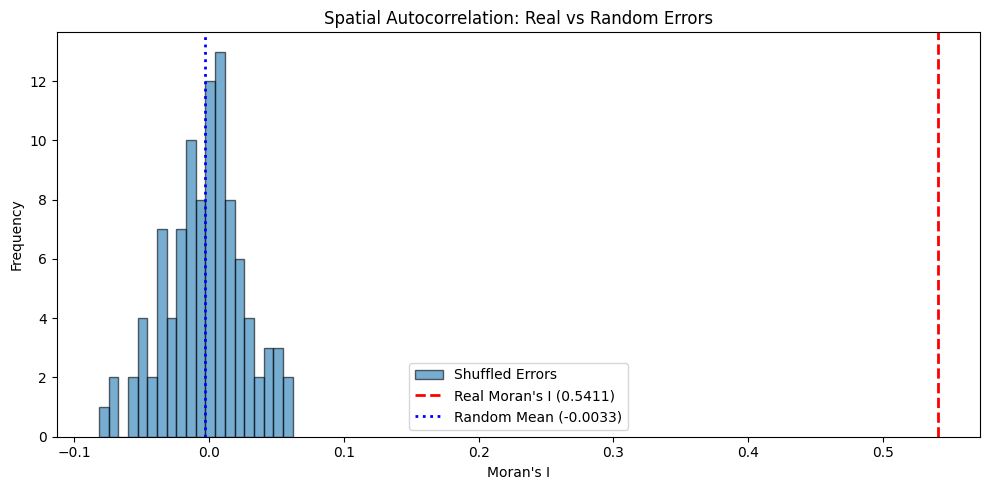


Real Moran's I is at 0.0th percentile of shuffled distribution
✓ Errors are MORE spatially clustered than random (I: 0.5411 vs mean: -0.0033)


In [31]:
# Validate against randomness: shuffle errors and compute Moran's I
print("\nValidating against randomness (100 shuffles)...")
n_shuffles = 100
random_morans = []

# Convert W to dense numpy for fast operations
W_dense = W.numpy() if hasattr(W, 'numpy') else np.asarray(W)

for i in range(n_shuffles):
    error_shuffled = np.random.permutation(error)
    I_random = morans_i_fast(error_shuffled, W_dense)
    random_morans.append(I_random)
    if (i + 1) % 25 == 0:
        print(f"  {i + 1}/{n_shuffles} shuffles completed")

random_morans = np.array(random_morans)
print(f"\nReal Moran's I: {morans_i_stat:.4f}")
print(f"Random mean: {np.mean(random_morans):.4f} ± {np.std(random_morans):.4f}")
print(f"Random range: [{np.min(random_morans):.4f}, {np.max(random_morans):.4f}]")

# Visualize real vs random distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(random_morans, bins=20, alpha=0.6, label="Shuffled Errors", edgecolor='black')
ax.axvline(morans_i_stat, color='red', linestyle='--', linewidth=2, label=f"Real Moran's I ({morans_i_stat:.4f})")
ax.axvline(np.mean(random_morans), color='blue', linestyle=':', linewidth=2, label=f"Random Mean ({np.mean(random_morans):.4f})")
ax.set_xlabel("Moran's I")
ax.set_ylabel("Frequency")
ax.set_title("Spatial Autocorrelation: Real vs Random Errors")
ax.legend()
plt.tight_layout()
plt.show()

# Statistical significance
percentile = np.sum(random_morans >= morans_i_stat) / len(random_morans) * 100
print(f"\nReal Moran's I is at {percentile:.1f}th percentile of shuffled distribution")
if morans_i_stat > np.mean(random_morans):
    print(f"✓ Errors are MORE spatially clustered than random (I: {morans_i_stat:.4f} vs mean: {np.mean(random_morans):.4f})")
else:
    print(f"✗ Errors are LESS spatially clustered than random (I: {morans_i_stat:.4f} vs mean: {np.mean(random_morans):.4f})")

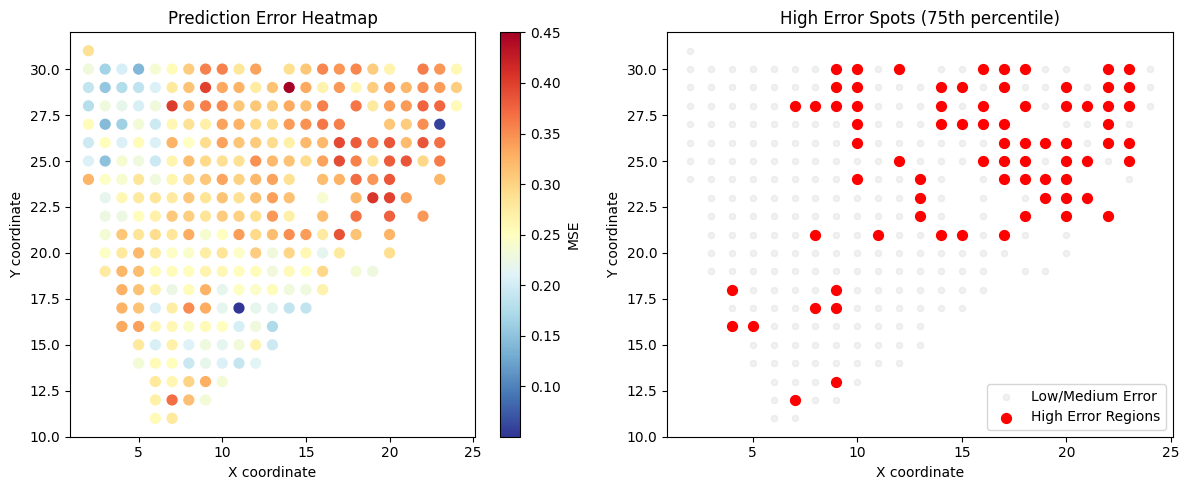

In [32]:
# Heatmap of errors on tissue
fig, axes = plt.subplots(1,2, figsize=(12,5))

# True error distribution
scatter = axes[0].scatter(coords[:,0], coords[:,1], c=error, cmap='RdYlBu_r', s=50)
axes[0].set_title('Prediction Error Heatmap')
axes[0].set_xlabel('X coordinate')
axes[0].set_ylabel('Y coordinate')
plt.colorbar(scatter, ax=axes[0], label='MSE')

# Spatially clustered high-error regions
high_error_mask = error > np.percentile(error, 75)
axes[1].scatter(coords[:,0], coords[:,1], c='lightgray', s=20, alpha=0.3, label='Low/Medium Error')
axes[1].scatter(coords[high_error_mask,0], coords[high_error_mask,1], 
                c='red', s=50, label='High Error Regions')
axes[1].set_title('High Error Spots (75th percentile)')
axes[1].set_xlabel('X coordinate')
axes[1].set_ylabel('Y coordinate')
axes[1].legend()
plt.tight_layout()
plt.show()

Error statistics by region label:
adipose tissue           : Mean Error = 0.3198 ± 0.0575 (n=70)
breast glands            : Mean Error = 0.3078 ± 0.0480 (n=41)
connective tissue        : Mean Error = 0.2786 ± 0.0477 (n=95)
invasive cancer          : Mean Error = 0.2420 ± 0.0506 (n=63)


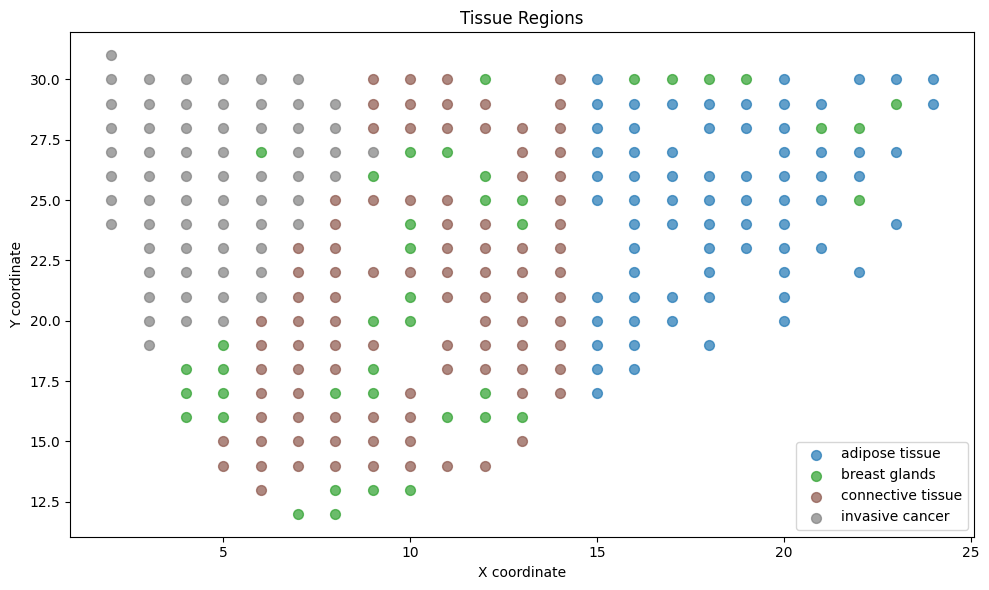

In [33]:
# Correlate error with region labels and biological insights
print("Error statistics by region label:")
print("=" * 50)

labels = testset.label[testset.names[0]]

if labels is not None:
    unique_labels = np.unique(labels)
    
    # Check if labels are strings or integers
    is_string_labels = isinstance(unique_labels[0], (str, np.str_))
    
    for label_id in unique_labels:
        # Skip undetermined labels
        if label_id == -1 or label_id == 'undetermined':
            continue
        
        # Get label name (either use mapping for numeric or use string directly)
        if is_string_labels:
            label_name = label_id
        else:
            lbl2name = {v: k for k, v in testset.lbl2id.items()}
            label_name = lbl2name.get(int(label_id), f"Unknown ({label_id})")
        
        mask = labels == label_id
        avg_error = error[mask].mean()
        std_error = error[mask].std()
        count = mask.sum()
        print(f"{label_name:25s}: Mean Error = {avg_error:.4f} ± {std_error:.4f} (n={count})")
else:
    print("No labels available for this sample")

# Visualize errors by region
if labels is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    
    for idx, label_id in enumerate(sorted(unique_labels)):
        if label_id == -1 or label_id == 'undetermined':
            continue
        mask = labels == label_id
        ax.scatter(coords[mask,0], coords[mask,1], label=str(label_id), s=50, alpha=0.7, color=colors[idx])
    
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_title('Tissue Regions')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

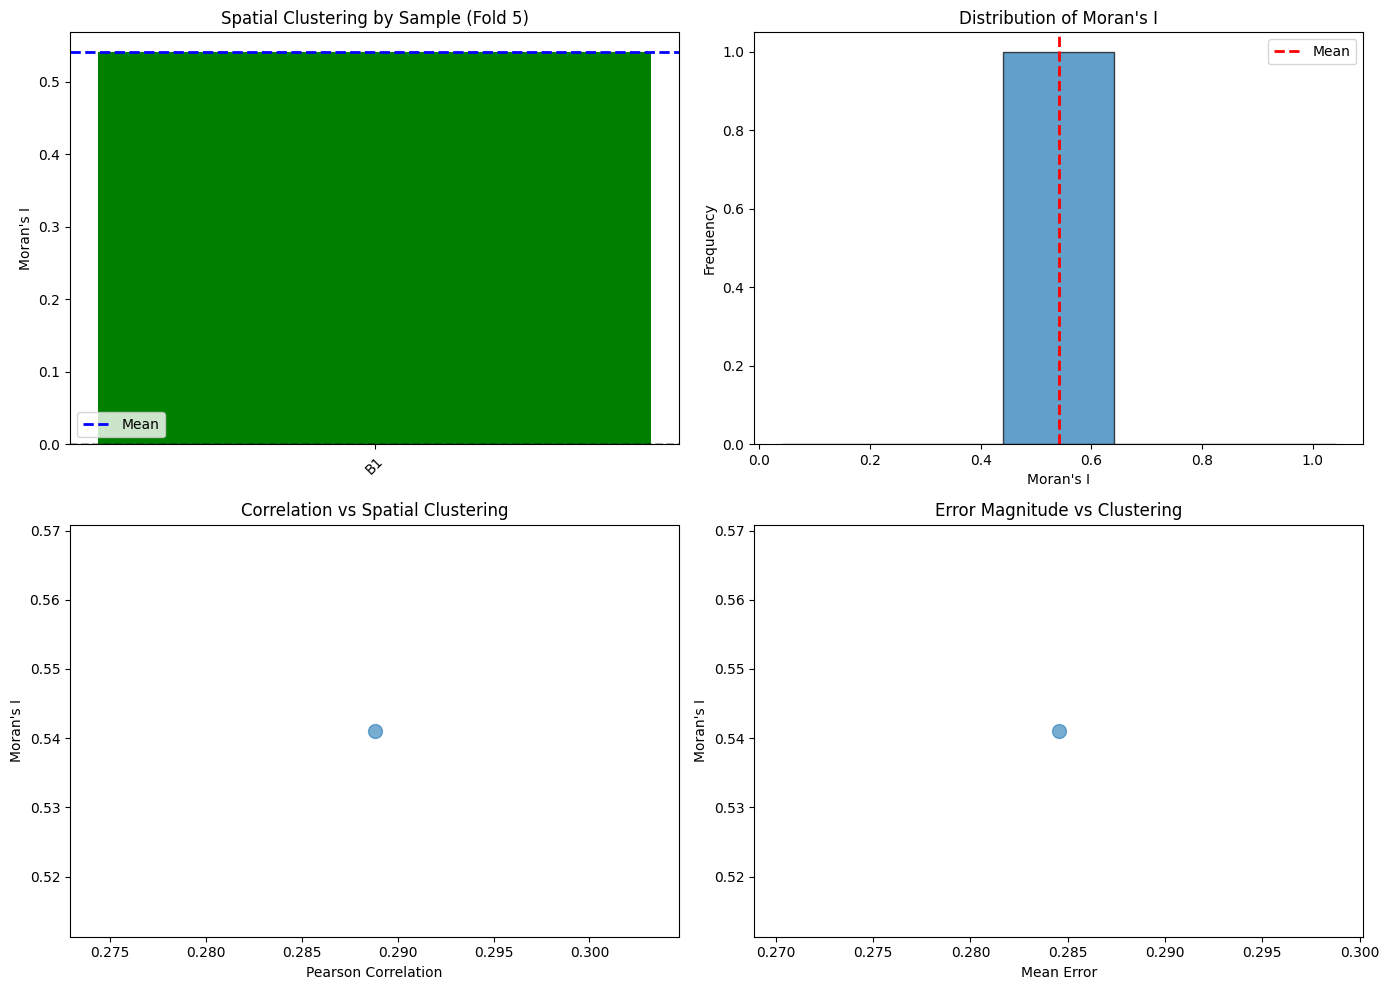


✓ All-samples validation complete!


In [37]:
# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].bar(range(len(results_df)), results_df['morans_i'], 
              color=['green' if x > 0 else 'red' for x in results_df['morans_i']])
axes[0,0].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[0,0].axhline(results_df['morans_i'].mean(), color='blue', linestyle='--', linewidth=2, label='Mean')
axes[0,0].set_xticks(range(len(results_df)))
axes[0,0].set_xticklabels(results_df['sample'], rotation=45)
axes[0,0].set_ylabel("Moran's I")
axes[0,0].set_title("Spatial Clustering by Sample (Fold 5)")
axes[0,0].legend()

# Histogram with minimum 5 bins
n_bins = max(5, len(results_df) // 2)
axes[0,1].hist(results_df['morans_i'], bins=n_bins, edgecolor='black', alpha=0.7)
axes[0,1].axvline(results_df['morans_i'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0,1].set_xlabel("Moran's I")
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title("Distribution of Moran's I")
axes[0,1].legend()

axes[1,0].scatter(results_df['pearson_r'], results_df['morans_i'], s=100, alpha=0.6)
axes[1,0].set_xlabel('Pearson Correlation')
axes[1,0].set_ylabel("Moran's I")
axes[1,0].set_title("Correlation vs Spatial Clustering")

axes[1,1].scatter(results_df['mean_error'], results_df['morans_i'], s=100, alpha=0.6)
axes[1,1].set_xlabel('Mean Error')
axes[1,1].set_ylabel("Moran's I")
axes[1,1].set_title("Error Magnitude vs Clustering")

plt.tight_layout()
plt.show()

print("\n✓ All-samples validation complete!")